<a href="https://colab.research.google.com/github/derekwilsonyt/HandsOnDeepLearning/blob/main/Derek_Wilson_of_HODL_SP26_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Before you do anything else, make a copy of this notebook.**

**Then, follow the instructions below to do the homework. Your final submission will just be a link to your copy of the notebook.**

## SETUP

Execute the code cells below and then proceed to the instructions.

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Download the data:

In [ ]:
(x_train, y_train), (x_val, y_val) = keras.datasets.california_housing.load_data(
    version="large", path="california_housing.npz", test_split=0.2, seed=113
)

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


Scale down the y values to make the MSE numbers less annoying to look at.

In [ ]:
y_train = y_train/1000.0
y_val = y_val/1000.0

## INSTRUCTIONS

### Dataset

Edited from https://keras.io/api/datasets/california_housing/

You have downloaded the (famous?) California Housing dataset. This dataset was derived from the 1990 U.S. census.

Each row of the data is for a **block group**. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data and typically has a population of 600-3,000 people.

This is a regression dataset with 8 features (i.e., **independent** variables). The target variable (i.e., the **dependent** variable) is the median house value in block group, in thousands of dollars.

The 8 input features are the following:

* Latitude: block group latitude
* Longitude: block group longitude
* HouseAge: median house age in block group
* TotRooms: Total number of rooms per household in block group
* TotBedrms: Total number of bedrooms per household in block group
* Population: Population of block group
* TotOccup: Total number of households in block group
* MedInc: median income in block group

(the order of the input features does not matter for this problem)



The 20,640 rows of data have been split into train and validation sets and stored in numpy arrays.
* `x_train`, `x_val`: numpy arrays containing the training and validation X matrices, respectively.

* `y_train`, `y_val`: numpy arrays containing the values of the dependent variable for the training and validation sets respectively. These are numbers typically between 25 and 500 and represent home prices in thousands of dollars.

### Assignment

To answer the questions below, feel free to use/re-use the code in the [Neural Heart Disease Prediction Model colab](https://colab.research.google.com/drive/1TC9qGjGaCdp68BIiGWQDgIKAa1a6J57y?usp=drive_link) that we covered in class.

First, standardize `x_train` and `x_val` using the mean and standard deviation of `x_train`. Then complete the following four parts.

Part I
* Set the random seed: `keras.utils.set_random_seed(42)`
* Define a Keras model with a single hidden layer of 16 neurons
* Use `model.compile` with `adam` as the optimizer and `mse` as the loss
* Train the Keras model for 100 epochs with `model.fit`, using a batch size of 32.
* Plot loss curves for the training and validation sets.
* From the loss curves, do you see any evidence of overfitting? Comment briefly.
* Evaluate the model on the validation set and report the MSE.


Part II
* Set the random seed: `keras.utils.set_random_seed(42)`
* Take the Keras model you defined in Part I and add another hidden layer of 16 neurons. Then repeat the steps from Part I.

Part III
* Set the random seed: `keras.utils.set_random_seed(42)`
* Take the Keras model you defined in Part I. Modify it so that the input layer is connected directly to the output layer as well (i.e., the input layer should be connected to the hidden layer **AND** the output layer). Then repeat the steps from Part I.

Hint: Use `keras.layers.Concatenate`

Part IV
* Set the random seed: `keras.utils.set_random_seed(42)`

Using Keras Tuner, do hyperparameter optimization across:
- the number of layers: [1,2,3]
- the number of units in each layer: [4, 8, 16]

(i.e., 9 hyper-parameter combinations)

For this part, the input layer should be connected only to the first hidden layer like we normally do (**NOT** like what we asked you to do in Part III).


Answer these questions in text cells:
* What is the optimal hyper-parameter combination?
* What is the MSE of the optimal model?
* How does this optimal model's MSE compare to the MSE of the models found in Parts I, II and III?

**COMPLETE ALL THE ABOVE BY ADDING CODE AND TEXT CELLS TO THIS NOTEBOOK BELOW THIS CELL.**

In [ ]:
#First, standardize x_train and x_val using the mean and standard deviation of x_train. Then complete the following four parts.

mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

x_train = (x_train - mean) / std
x_val = (x_val - mean) / std

In [ ]:
x_train.shape, x_val.shape

((16512, 8), (4128, 8))

### Part I

In [ ]:
#Set the random seed: keras.utils.set_random_seed(42)

keras.utils.set_random_seed(42)

In [ ]:
#Define a Keras model with a single hidden layer of 16 neurons

input = keras.layers.Input(shape=x_train.shape[1:])
h = keras.layers.Dense(16, activation="relu")(input)
output = keras.layers.Dense(1)(h)
model = keras.Model(input, output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Use model.compile with adam as the optimizer and mse as the loss

model.compile(optimizer="adam",
              loss="mse",
              )

In [ ]:
#Train the Keras model for 100 epochs with model.fit, using a batch size of 32.

history = model.fit(x_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    verbose=1,
                    validation_data=(x_val,y_val))


Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 53927.9805 - val_loss: 49814.6094
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45726.5156 - val_loss: 37006.8242
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32961.6875 - val_loss: 24517.8750
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 21725.7715 - val_loss: 16055.4639
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14664.1865 - val_loss: 11856.8584
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11273.1553 - val_loss: 9936.3584
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9587.9219 - val_loss: 8784.0020
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8448.4053 - val_loss: 7910.3857
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7546.4204 - val_loss: 7210.1279
Epoch 10/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6815.4639 - val_loss: 6652.7935
Epoch 11/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

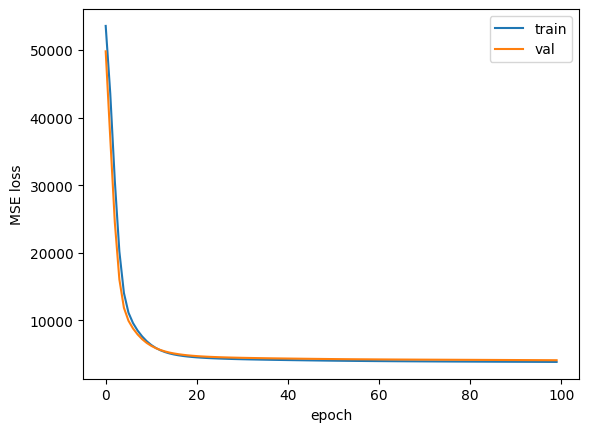

In [ ]:
#Plot loss curves for the training and validation sets.

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.ylabel('MSE loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

### Q. From the loss curves, do you see any evidence of overfitting? Comment briefly.

There doesn't appear to be evidence of overfitting. The loss for the training set and validation set decline and stabalize roughly in parallel. We don't see the loss for the training set declining to 0 or the loss for the validation set increasing after a certain point, which would indicate overfitting.

In [ ]:
#Evaluate the model on the validation set and report the MSE

model.evaluate(x_val, y_val, verbose=0)
print("Validation MSE Part I:", model.evaluate(x_val, y_val, verbose=0))

Validation MSE Part I: 4090.94287109375


### Part II

In [ ]:
#Set the random seed: keras.utils.set_random_seed(42)

keras.utils.set_random_seed(42)

In [ ]:
#Take the Keras model you defined in Part I and add another hidden layer of 16 neurons.

input = keras.layers.Input(shape=x_train.shape[1:])
h1 = keras.layers.Dense(16, activation="relu")(input)
h2 = keras.layers.Dense(16, activation="relu")(h1)
output = keras.layers.Dense(1)(h2)
model = keras.Model(input, output)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433 (1.69 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 51310.2344 - val_loss: 17511.7988
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12871.4443 - val_loss: 7825.1035
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7332.0591 - val_loss: 6338.3267
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5845.1694 - val_loss: 5457.7686
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4985.3809 - val_loss: 4957.1641
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4527.9292 - val_loss: 4722.9927
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4309.6084 - val_loss: 4598.6665
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4190.2646 - val_loss: 4519.8555
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4109.5537 - val_loss: 4465.8799
Epoch 10/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4050.8491 - val_loss: 4424.7368
Epoch 11/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4004

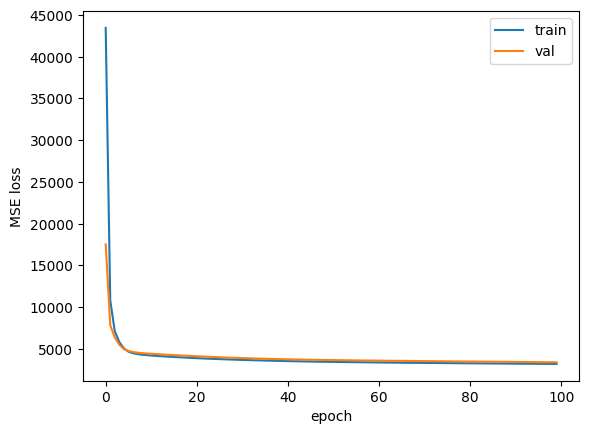

In [ ]:
#Then repeat the steps from Part I

#compile
model.compile(optimizer="adam",
              loss="mse",
              )

#train
history = model.fit(x_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    verbose=1,
                    validation_data=(x_val,y_val))

#plot
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.ylabel('MSE loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
#evaluate

model.evaluate(x_val, y_val, verbose=0)
print("Validation MSE Part II:", model.evaluate(x_val, y_val, verbose=0))

Validation MSE Part II: 3370.6884765625


### Part III

In [ ]:
#Set the random seed: keras.utils.set_random_seed(42)

keras.utils.set_random_seed(42)

In [ ]:
#Take the Keras model you defined in Part I. Modify it so that the input layer is connected directly to the output layer as well
#Hint: Use keras.layers.Concatenate

input = keras.layers.Input(shape=x_train.shape[1:])
h = keras.layers.Dense(16, activation="relu")(input)
concat = keras.layers.Concatenate()([input, h])
output = keras.layers.Dense(1)(concat)
model = keras.Model(input, output)

Epoch 1/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 54074.8945 - val_loss: 50097.6836
Epoch 2/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45962.9414 - val_loss: 36960.0859
Epoch 3/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32777.9844 - val_loss: 23680.1816
Epoch 4/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20658.4609 - val_loss: 14558.2314
Epoch 5/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13036.6445 - val_loss: 10341.9893
Epoch 6/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9739.7383 - val_loss: 8842.3760
Epoch 7/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8513.4658 - val_loss: 8150.6841
Epoch 8/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7830.5371 - val_loss: 7608.7876
Epoch 9/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7249.1772 - val_loss: 7113.6426
Epoch 10/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6724.1372 - val_loss: 6670.9927
Epoch 11/100
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - los

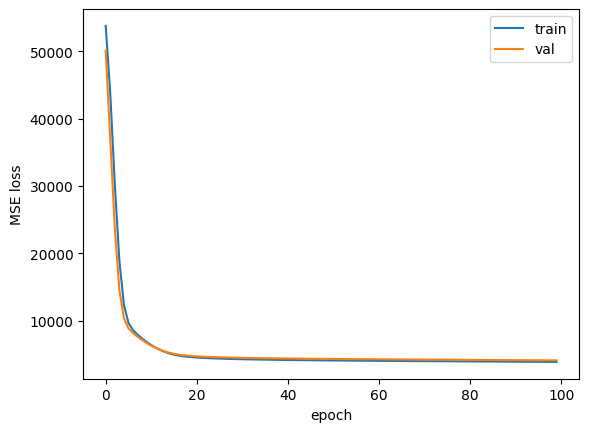

In [ ]:
#repeat the steps from Part I

#compile
model.compile(optimizer="adam",
              loss="mse",
              )

#train
history = model.fit(x_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    verbose=1,
                    validation_data=(x_val,y_val))

#plot
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.ylabel('MSE loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

In [ ]:
#evaluate

model.evaluate(x_val, y_val, verbose=0)
print("Validation MSE Part III:", model.evaluate(x_val, y_val, verbose=0))

Validation MSE Part III: 4092.591552734375


### Part IV

In [ ]:
#Set the random seed: keras.utils.set_random_seed(42)

keras.utils.set_random_seed(42)

In [ ]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.7 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

In [ ]:
#Using Keras Tuner, do hyperparameter optimization across:
#the number of layers: [1,2,3]
#the number of units in each layer: [4, 8, 16]
#(i.e., 9 hyper-parameter combinations)
#For this part, the input layer should be connected only to the first hidden layer like we normally do.

def build_model(hp):
    input = keras.layers.Input(shape=x_train.shape[1:])
    x = input

    num_layers = hp.Choice('num_layers', [1, 2, 3])
    units = hp.Choice('units', [4, 8, 16])

    for _ in range(num_layers):
        x = keras.layers.Dense(units, activation="relu")(x)

    output = keras.layers.Dense(1)(x)

    model = keras.Model(input, output)

    model.compile(optimizer="adam",
              loss="mse")

    return model


In [ ]:
# Initialize the tuner
tuner = kt.GridSearch(
    build_model,
    objective='val_loss',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 2
num_layers (Choice)
{'default': 1, 'conditions': [], 'values': [1, 2, 3], 'ordered': True}
units (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8, 16], 'ordered': True}


In [ ]:
tuner.search(x_train,
             y_train,
             epochs=100,
             batch_size=32,
             verbose=1,
             validation_data=(x_val, y_val))


Trial 9 Complete [00h 02m 01s]
val_loss: 3314.176513671875

Best val_loss So Far: 3314.176513671875
Total elapsed time: 00h 17m 42s


In [ ]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0008 summary
Hyperparameters:
num_layers: 3
units: 16
Score: 3314.176513671875

Trial 0005 summary
Hyperparameters:
num_layers: 2
units: 16
Score: 3340.593017578125

Trial 0004 summary
Hyperparameters:
num_layers: 2
units: 8
Score: 3722.120361328125

Trial 0007 summary
Hyperparameters:
num_layers: 3
units: 8
Score: 3841.385986328125

Trial 0002 summary
Hyperparameters:
num_layers: 1
units: 16
Score: 4199.8154296875

Trial 0001 summary
Hyperparameters:
num_layers: 1
units: 8
Score: 4235.580078125

Trial 0003 summary
Hyperparameters:
num_layers: 2
units: 4
Score: 4310.60546875

Trial 0006 summary
Hyperparameters:
num_layers: 3
units: 4
Score: 4399.03173828125

Trial 0000 summary
Hyperparameters:
num_layers: 1
units: 4
Score: 4584.447265625


In [ ]:
best_model = tuner.get_best_models(1)[0]

best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
best_model.evaluate(x_val, y_val, verbose=0)

3314.176513671875

### Q. What is the optimal hyper-parameter combination?

The optimal hyper-parameter combination is to have 3 dense (hidden) layers, with 16 units (neurons) per layer.


### Q. What is the MSE of the optimal model?

The MSE of the optimal model is 3314.18



### Q. How does this optimal model's MSE compare to the MSE of the models found in Parts I, II and III?

The MSE of the optimal model (3314.18) represents a significant improvement over the MSE in Part I (4090.94) and Part III (4092.59), but only a marginal improvement over the MSE of part II (3370.69).

MSE Part I: 4090.94

MSE Part II: 3370.69

MSE Part III: 4092.59

MSE Part IV (optimal): 3314.18